# Modern Signal Analysis and Signal Processing · Homework Code (Python)

This notebook provides a Python version code of solving ODE using convolution and Green function by numerical method.

Modified by Haozheng Ji (jihz2023@mail.sustech.edu.cn) on April 11, 2026.

## Reference Implementations

- **Harmonic_Oscillator.m** — Provided by Haoran Meng

## Dependencies

- `numpy`
- `matplotlib`

In [1]:
import numpy  as np
import matplotlib.pyplot as plt

# Green's Function Solution for $m\ddot{x}+c\dot{x}+kx=U_t$, where $U_t$ is a step function
## Use the 4th-order Runge-Kutta method to numerically solve the oscillator equation $\hat{L}G_u=U_t$, then obtain the Green function of delta function $G_\delta$ by differentiating $G_u$
The `RK4` function numerically solves the differential equation using the classic 4th-order Runge-Kutta algorithm.

Damping cases for $c$:
- $c=2\sqrt{\frac{k}{m}}$: critically damped
- $c<2\sqrt{\frac{k}{m}}$: underdamped
- $c>2\sqrt{\frac{k}{m}}$: overdamped

# For convenience, the external force is defined as a scalar function to simplify its use with the RK4 method.

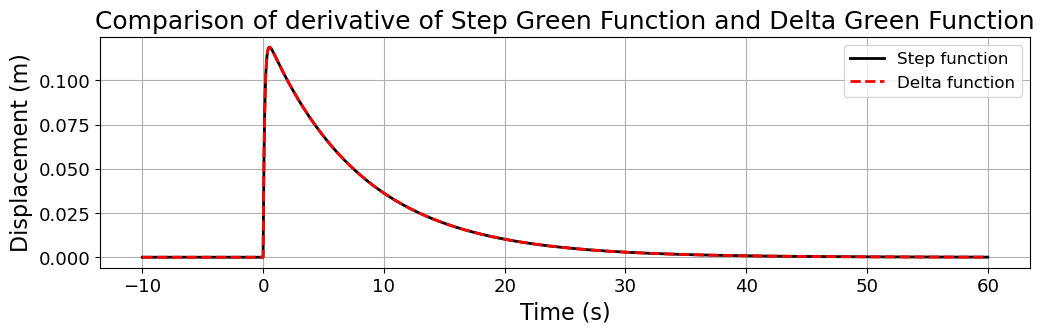

In [ ]:
def RK4(f,x00,x10,h,time):
    x=np.zeros([2,len(time)])
    x[0,0]=x00
    x[1,0]=x10
    for ii in range(len(time)-1):
        k1=np.array([x[1,ii],f(time[ii],x[0,ii],x[1,ii])])
        k2=np.array([x[1,ii]+h/2*k1[1],f(time[ii]+h/2,x[0,ii]+h/2*k1[0],x[1,ii]+h/2*k1[1])])
        k3=np.array([x[1,ii]+h/2*k2[1],f(time[ii]+h/2,x[0,ii]+h/2*k2[0],x[1,ii]+h/2*k2[1])])
        k4=np.array([x[1,ii]+h*k3[1],f(time[ii]+h,x[0,ii]+h*k3[0],x[1,ii]+h*k3[1])])
        x[:,ii+1]=x[:,ii]+h/6*(k1+2*k2+2*k3+k4)
    return x

## NOTICE: There, for using Runge kutta solver easily we set the force function be a scale function
def step_function(t):
    if t<0: return 0
    else: return 1
def delta_function(t):
    # a better choice
    if abs(t)<h/2: return 1/h
    else: return 0
    # if abs(t)<0.5: return 1
    # else: return 0

def make_f(force_func):
    def f_local(t,x0,x1):
        return (force_func(t)-c*x1-k*x0)/m
    return f_local
m=1 # mass (kg)
k=1 # spring constant (N/m)
# damping coefficient (N/(m/s)) critically c = 2(k/m)^0.5
# change c under damp< critically < over 0.01<2<8
c=8
x00=0 # initial displacement
x10=0 # initial velocity
h=0.01 # numerical time step
time=np.arange(-10,60+h,h)

x_step=RK4(make_f(step_function),x00,x10,h,time)
kernel = x_step[1,:]

x_delta=RK4(make_f(delta_function),x00,x10,h,time)
## compare the Green function solved by the derivative of step force's Green function and 
Linsize,Labsize,Titsize,Legsize,Ticsize=2,16,18,12,13
plt.figure(figsize=(12,3))
plt.plot(time,x_step[1,:],color='k',linewidth=Linsize,label="Step function")
plt.plot(time,x_delta[0,:],'r--',linewidth=Linsize,label="Delta function")
plt.xlabel("Time (s)",fontsize=Labsize)
plt.ylabel("Displacement (m)",fontsize=Labsize)
plt.legend(loc='upper right',fontsize=Legsize)
plt.grid()
plt.tick_params(axis='both', which='major', labelsize=Ticsize)
plt.title("Comparison of derivative of Step Green Function and Delta Green Function", fontsize=Titsize)
plt.savefig("CompareGreenFunction_over.png",dpi=300)
plt.show()


## Using Arbitrary Force Inputs

The `conv` function below computes the convolution of two vectors: the system's Green function/kernel and an arbitrary input force.  

You can also use NumPy's built-in `np.convolve` for convolution, which is faster and often more convenient.  

To proceed, you may use either the Green function obtained from a step input ($G_u'$) or the delta input ($G_\delta$) as your convolution kernel.

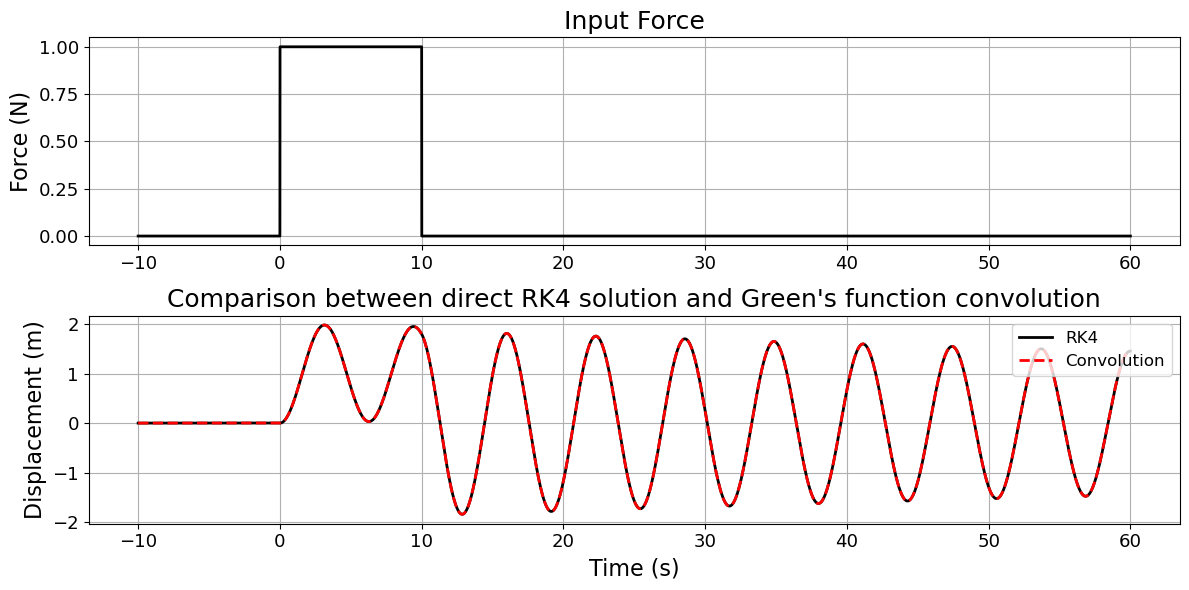

In [27]:
# kernel = x_step[1,:]
kernel = x_delta[0,:]

def conv(kernel, force):
    N, M = len(kernel), len(force)
    output = np.zeros(N + M - 1)
    for ii in range(N + M - 1):
        s = 0.0
        for jj in range(N):
            if 0<ii - jj < M:
                s += kernel[jj] * force[ii - jj]
        output[ii] = s

    return output

def force1(t):
    if t<0: return 0
    else: return np.sin(5*t) * np.exp(-t)
def force2(t):
    if t < 0: return 0
    else: return np.exp(-t)
def force3(t):
    if t<0: return 0
    elif t<10: return t
    elif t<20: return 20-t
    else: return 0
def force4(t):
    if t<0: return 0
    elif t<10: return t
    elif t<30: return 15-0.5*t
    else: return 0
def force5(t):
    if t<0: return 0
    else: return np.sin(2*t)
def force6(t):
    if 0<t<10: return 1
    else: return 0

vec_force=np.array([force6(t) for t in time]) ## change the force numer 
x_0=RK4(make_f(force6),x00,x10,h,time)

shift=np.sum(time<0)
x_1=conv(kernel,vec_force)*h
# x_1=np.convolve(kernel,vec_force)*h # faster

plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(time, vec_force,'k', linewidth=Linsize)
plt.title("Input Force", fontsize=Titsize)
plt.ylabel("Force (N)", fontsize=Labsize)
plt.grid()
plt.tick_params(axis='both', which='major', labelsize=Ticsize)
plt.subplot(2,1,2)
plt.plot(time, x_0[0,:], color='k', linewidth=Linsize, label="RK4")
plt.plot(time, x_1[shift:shift+len(time)], 'r--', linewidth=Linsize, label="Convolution")

plt.xlabel("Time (s)", fontsize=Labsize)
plt.ylabel("Displacement (m)", fontsize=Labsize)
plt.title("Comparison between direct RK4 solution and Green's function convolution", fontsize=Titsize)
plt.legend(loc='upper right', fontsize=Legsize)
plt.grid()
plt.tick_params(axis='both', which='major', labelsize=Ticsize)

plt.tight_layout()
# plt.savefig("force6.png",dpi=300)
plt.show()